# Chip Bets: scoring and comparing the submitted strategies

Each submitted entry lives in a `strategy.py.<Name>` file (see `README.md` for the game rules).
This notebook

1. loads every submission,
2. scores each one with the same engine as `sim.py` at the official seed (`14338`),
3. reruns the contest over many seeds, since one seed is a single draw of luck,
4. compares the final banks, the bank paths, betting accuracy and chip spending.

`run_contest` below is a copy of `sim.get_bank` with three changes: it takes the strategy
function and the seed as arguments, it records a per-session trace, and it counts the error
exits (empty bag, bet ≥ bank, …) instead of only logging them. A check cell confirms that it
gives the same result as `sim.py`.

In [1]:
import logging
import os
import random
import sys

# sim_parameters.py calls logging.basicConfig(filename='session.log', level=DEBUG).
# Give the root logger a handler first so that call is a no-op and we don't write
# a huge debug log while running thousands of contests.
logging.getLogger().addHandler(logging.NullHandler())
logging.getLogger().setLevel(logging.CRITICAL)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.getcwd())
from sim_parameters import n_wd_w, n_wd_r, n_rd_w, n_rd_r, chip_cost
from submissions import load_all

OFFICIAL_SEED = 14338
N_SESSIONS = 100
START_BANK = 1000

## Load the submissions

`submissions.load_all()` imports every `strategy.py.<Name>` file in this folder, so nothing
has to be copied over `strategy.py`. The same loader is behind `./sim.py <Name>`.

In [2]:
strategies = load_all()
list(strategies)

['AI1', 'AI2', 'FirstChip', 'Jeff', 'Josh', 'Random']

## Contest engine

Same rules and the same order of `random` calls as `sim.get_bank`, so a given seed produces
the same bags and the same bag sequence for every strategy. Strategies that call `random`
themselves (e.g. *Random*) share the global generator, just as they do in `sim.py`; the
bags and bag sequence are drawn before any strategy is called, so this does not change
them.

In [3]:
def run_contest(bet_strategy, seed, n_sessions=N_SESSIONS, bank=START_BANK, **kwargs):
    random.seed(a=seed)
    white_dominant = ["w"] * n_wd_w + ["r"] * n_wd_r
    red_dominant = ["r"] * n_rd_r + ["w"] * n_rd_w
    random.shuffle(white_dominant)
    random.shuffle(red_dominant)
    bags = {"wd": white_dominant, "rd": red_dominant}

    bag_keys = [random.choice(["rd", "wd"]) for _ in range(n_sessions)]

    trace = []
    n_session = 0
    while bank >= 0 and n_session < n_sessions:
        bag_key = bag_keys[n_session]
        chip_color = "u"
        session_history = []
        rec = dict(session=n_session, bag=bag_key, chips=0, bet=0,
                   bet_bag=None, correct=None, error=None)
        while True:
            move_choice, bet, bet_bag = bet_strategy(n_session, bank, chip_color, session_history, **kwargs)
            if move_choice.lower() == "bet":
                chip_color = "u"
                bet = max(int(bet), 1)
                if bank > bet:
                    bank += bet if bet_bag == bag_key else -bet
                    rec.update(bet=bet, bet_bag=bet_bag, correct=(bet_bag == bag_key))
                    break
                rec["error"] = "bet >= bank"
                break
            elif move_choice.lower() == "buy":
                try:
                    chip_color = bags[bag_key].pop()
                except IndexError:
                    rec["error"] = "bag empty"
                    break
                if bank > chip_cost:
                    bank -= chip_cost
                    rec["chips"] += 1
                else:
                    rec["error"] = "bank < chip cost"
                    break
            else:
                rec["error"] = "invalid move"
                break
            session_history.append((move_choice, bet, bet_bag, chip_color))
        rec["bank"] = bank
        trace.append(rec)
        n_session += 1
    return bank, pd.DataFrame(trace)

### Check against `sim.py`

Score every submission with both `sim.get_bank` and `run_contest` at the official seed;
the two must agree.

In [4]:
import sim

for name, fn in strategies.items():
    official = sim.get_bank(fn)
    mine, _ = run_contest(fn, OFFICIAL_SEED)
    print(f"{name:>10}  sim.get_bank() = ${official:,.2f}   run_contest() = ${mine:,.2f}")
    assert abs(official - mine) < 1e-9, name

       AI1  sim.get_bank() = $1,291,588,844,363,428.00   run_contest() = $1,291,588,844,363,428.00
       AI2  sim.get_bank() = $196,496,589,879,998.53   run_contest() = $196,496,589,879,998.53
 FirstChip  sim.get_bank() = $14,960,524.00   run_contest() = $14,960,524.00
      Jeff  sim.get_bank() = $72,534.00   run_contest() = $72,534.00
      Josh  sim.get_bank() = $290.00   run_contest() = $290.00
    Random  sim.get_bank() = $0.40   run_contest() = $0.40


## Score at the official seed

In [5]:
official_rows, official_traces = [], {}
for name, fn in strategies.items():
    final, trace = run_contest(fn, OFFICIAL_SEED)
    official_traces[name] = trace
    bets = trace[trace.bet > 0]
    official_rows.append(dict(
        strategy=name,
        final_bank=round(final, 2),
        bets_placed=len(bets),
        accuracy=bets.correct.mean(),
        chips_bought=trace.chips.sum(),
        chip_spend=round(trace.chips.sum() * chip_cost, 2),
        errors=trace.error.notna().sum(),
    ))

official_scores = (pd.DataFrame(official_rows)
                   .sort_values("final_bank", ascending=False)
                   .reset_index(drop=True))
official_scores.index += 1
official_scores.style.format({"final_bank": "${:,.2f}", "chip_spend": "${:,.2f}", "accuracy": "{:.1%}"})

,strategy,final_bank,bets_placed,accuracy,chips_bought,chip_spend,errors
1,AI1,"$1,291,588,844,363,428.00",100,79.0%,300,"$2,790.00",0
2,AI2,"$196,496,589,879,998.53",100,79.0%,355,"$3,301.50",0
3,FirstChip,"$14,960,524.00",100,72.0%,100,$930.00,0
4,Jeff,"$72,534.00",100,72.0%,100,$930.00,0
5,Josh,$290.00,100,72.0%,100,$930.00,0
6,Random,$0.40,92,52.2%,92,$855.60,8


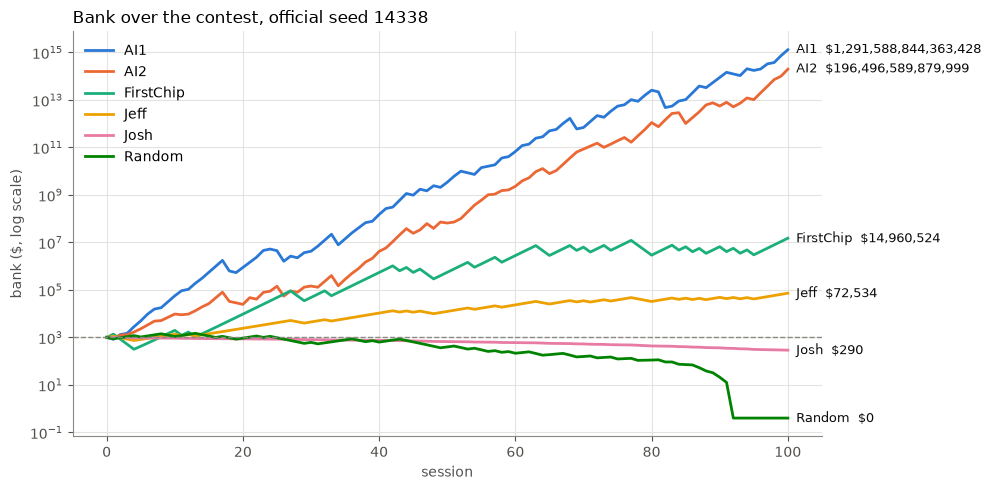

In [6]:
# Fixed colour per strategy (categorical palette, assigned in order, never by rank).
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
COLORS = {name: PALETTE[i % len(PALETTE)] for i, name in enumerate(strategies)}

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
})

fig, ax = plt.subplots(figsize=(10, 5))
for name, trace in official_traces.items():
    banks = np.concatenate([[START_BANK], trace.bank.values])
    ax.plot(range(len(banks)), banks, color=COLORS[name], lw=2, label=name)
    ax.annotate(f"{name}  ${banks[-1]:,.0f}", (len(banks) - 1, banks[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color="#0b0b0b")
ax.axhline(START_BANK, color="#8a8984", lw=1, ls="--")
ax.set_yscale("log")
ax.set_xlabel("session")
ax.set_ylabel("bank ($, log scale)")
ax.set_title(f"Bank over the contest, official seed {OFFICIAL_SEED}", loc="left")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## Many seeds

The official result depends on one shuffle of the bags and one sequence of bag choices.
Running every strategy on the same set of seeds shows which ones are good and which were
lucky. Every strategy sees the same bags for a given seed, so the comparisons are paired.

In [7]:
N_SEEDS = 500
seeds = range(1, N_SEEDS + 1)

rows = []
for seed in seeds:
    for name, fn in strategies.items():
        final, trace = run_contest(fn, seed)
        bets = trace[trace.bet > 0]
        rows.append(dict(seed=seed, strategy=name, final_bank=final,
                         accuracy=bets.correct.mean(), bets_placed=len(bets),
                         chips_bought=trace.chips.sum(),
                         errors=trace.error.notna().sum()))
results = pd.DataFrame(rows)
results.head()

,seed,strategy,final_bank,accuracy,bets_placed,chips_bought,errors
0,1,AI1,4.446189e+13,0.78,100,300,0
1,1,AI2,5.888926e+14,0.81,100,358,0
2,1,FirstChip,2.977180e+05,0.67,100,100,0
3,1,Jeff,2.135600e+04,0.67,100,100,0
4,1,Josh,2.400000e+02,0.67,100,100,0


In [8]:
wide = results.pivot(index="seed", columns="strategy", values="final_bank")
winner = wide.idxmax(axis=1)

summary = results.groupby("strategy").agg(
    mean_bank=("final_bank", "mean"),
    median_bank=("final_bank", "median"),
    p10_bank=("final_bank", lambda s: s.quantile(0.10)),
    p90_bank=("final_bank", lambda s: s.quantile(0.90)),
    p_lose_money=("final_bank", lambda s: (s < START_BANK).mean()),
    accuracy=("accuracy", "mean"),
    chips_per_contest=("chips_bought", "mean"),
    errors_per_contest=("errors", "mean"),
)
summary["win_rate"] = winner.value_counts(normalize=True).reindex(summary.index).fillna(0)
summary = summary.sort_values("median_bank", ascending=False)
summary.style.format({
    "mean_bank": "${:,.0f}", "median_bank": "${:,.0f}", "p10_bank": "${:,.0f}", "p90_bank": "${:,.0f}",
    "p_lose_money": "{:.1%}", "accuracy": "{:.1%}", "win_rate": "{:.1%}",
    "chips_per_contest": "{:.1f}", "errors_per_contest": "{:.2f}",
})

,mean_bank,median_bank,p10_bank,p90_bank,p_lose_money,accuracy,chips_per_contest,errors_per_contest,win_rate
strategy,,,,,,,,,
AI2,"$1,199,017,090,303,884","$73,954,511,255,023","$1,131,045,561,860","$2,005,812,859,531,573",2.2%,79.2%,352.0,0.00,84.8%
AI1,"$523,374,387,402,170","$2,484,920,912,741",$178,"$238,081,909,585,772",10.4%,74.3%,271.0,0.00,13.6%
FirstChip,"$186,232,573","$3,080,546","$18,598","$147,794,032",7.2%,69.0%,96.2,3.79,0.2%
Jeff,"$63,971","$43,304","$11,065","$139,595",0.4%,69.9%,100.0,0.03,1.2%
Josh,$269,$270,$220,$320,100.0%,69.9%,100.0,0.00,0.2%
Random,$272,$5,$0,$672,92.8%,48.1%,75.6,24.49,0.0%


`win_rate` is the share of seeds on which the strategy finished with the highest bank.
Mean and median can differ a lot: with fixed-fraction betting the bank grows
multiplicatively, so a few very good seeds pull the mean up. The median and the log-scale
plots below give the typical outcome.

/tmp/ipykernel_2214170/3233505898.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  parts = ax.boxplot(data, vert=False, widths=0.5, patch_artist=True,


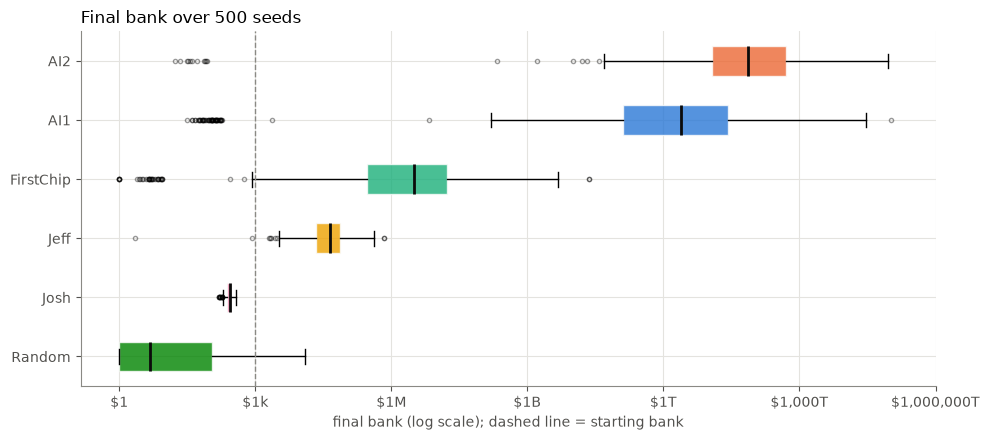

In [9]:
order = list(summary.index)
fig, ax = plt.subplots(figsize=(10, 4.5))
data = [np.log10(wide[name].clip(lower=1)) for name in order]
parts = ax.boxplot(data, vert=False, widths=0.5, patch_artist=True,
                   medianprops=dict(color="#0b0b0b", lw=2), flierprops=dict(marker="o", ms=3, alpha=0.4))
for patch, name in zip(parts["boxes"], order):
    patch.set_facecolor(COLORS[name]); patch.set_alpha(0.8); patch.set_edgecolor("#fcfcfb")
ax.axvline(np.log10(START_BANK), color="#8a8984", lw=1, ls="--")
def dollars(t):
    for exp, suffix in ((12, "T"), (9, "B"), (6, "M"), (3, "k")):
        if t >= exp:
            return f"${10 ** (t - exp):,.0f}{suffix}"
    return f"${10 ** t:,.0f}"

ticks = np.arange(0, np.ceil(max(d.max() for d in data)) + 1, 3)
ax.set_xticks(ticks, [dollars(t) for t in ticks])
ax.set_yticks(range(1, len(order) + 1), order)
ax.invert_yaxis()
ax.set_xlabel("final bank (log scale); dashed line = starting bank")
ax.set_title(f"Final bank over {N_SEEDS} seeds", loc="left")
plt.tight_layout()
plt.show()

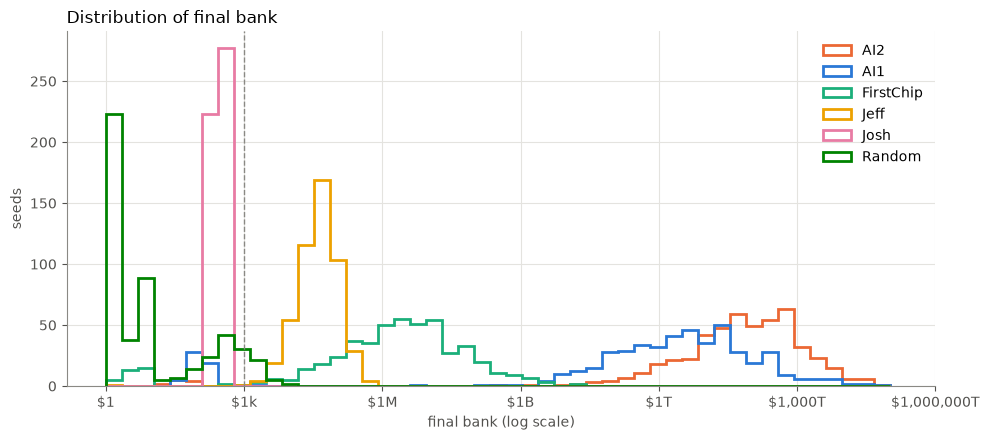

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.linspace(np.log10(wide.clip(lower=1).min().min()), np.log10(wide.max().max()), 50)
for name in order:
    ax.hist(np.log10(wide[name].clip(lower=1)), bins=bins, histtype="step", lw=2,
            color=COLORS[name], label=name)
ax.axvline(np.log10(START_BANK), color="#8a8984", lw=1, ls="--")
ax.set_xticks(ticks, [dollars(t) for t in ticks])
ax.set_xlabel("final bank (log scale)")
ax.set_ylabel("seeds")
ax.set_title("Distribution of final bank", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Head to head

Share of seeds on which the row strategy finished ahead of the column strategy.

In [11]:
h2h = pd.DataFrame(index=order, columns=order, dtype=float)
for a in order:
    for b in order:
        h2h.loc[a, b] = np.nan if a == b else (wide[a] > wide[b]).mean()
h2h.style.format("{:.0%}", na_rep="–").background_gradient(cmap="Blues", vmin=0, vmax=1)

,AI2,AI1,FirstChip,Jeff,Josh,Random
AI2,–,85%,99%,98%,98%,99%
AI1,15%,–,95%,90%,90%,98%
FirstChip,1%,5%,–,91%,93%,98%
Jeff,2%,10%,9%,–,100%,100%
Josh,2%,10%,7%,0%,–,80%
Random,1%,2%,2%,0%,20%,–


### How each strategy plays a session

Chips bought per session and bet size as a share of the bank, averaged over every session
of every seed. These two numbers explain most of the gap between strategies: buying
more chips raises accuracy but costs $9.30 each, and a larger bet fraction grows the bank
faster when accuracy is above 50% but risks ruin.

In [12]:
play_rows = []
for name, fn in strategies.items():
    for seed in list(seeds)[:100]:
        _, trace = run_contest(fn, seed)
        prev_bank = np.concatenate([[START_BANK], trace.bank.values[:-1]])
        bank_before_bet = prev_bank - trace.chips * chip_cost
        placed = trace.bet > 0
        play_rows.append(dict(
            strategy=name,
            chips_per_session=trace.chips.mean(),
            bet_fraction=(trace.bet[placed] / bank_before_bet[placed]).mean(),
            accuracy=trace.correct[placed].mean(),
        ))
play = pd.DataFrame(play_rows).groupby("strategy").mean().loc[order]
play.style.format({"chips_per_session": "{:.2f}", "bet_fraction": "{:.1%}", "accuracy": "{:.1%}"})

,chips_per_session,bet_fraction,accuracy
strategy,,,
AI2,3.50,54.3%,79.3%
AI1,2.67,48.7%,74.1%
FirstChip,0.96,37.9%,69.3%
Jeff,1.00,11.8%,70.1%
Josh,1.00,0.9%,70.1%
Random,0.76,12.5%,48.0%


## Adding another submission

Save it as `strategy.py.<Name>` in this folder and rerun the notebook (or score it alone
with `./sim.py <Name>`). It must define
`bet_strategy(session, bank, chip_color, session_history, **kwargs)` as described in
`README.md`.